# Evaluating LLM Outputs: Accuracy, BLEU, ROUGE

| Section | Time |
|---|---|
| 1. Which metric for which task | 2 min |
| 2. Accuracy (and its two traps) | 5 min |
| 3. BLEU | 6 min |
| 4. ROUGE | 5 min |
| 5. Failure modes + exercises | 2 min + optional |

**Format:** each metric is built from scratch, then verified against the reference library (`sacrebleu`, `rouge-score`). Cells marked **Predict** should be answered *before* running.

## 1. Which metric for which task

| Metric | Typical task | What it compares | Emphasis |
|---|---|---|---|
| **Accuracy** | Classification, multiple-choice (MMLU), extraction | prediction vs. single gold label | exact correctness |
| **BLEU** | Machine translation | n-gram overlap of output vs. reference | **precision** |
| **ROUGE** | Summarization | n-gram / subsequence overlap vs. reference | **recall** (report F1 too) |

All three are **reference-based**: they need a gold answer. BLEU and ROUGE measure *surface overlap*, not meaning. Section 5 shows what that costs.

In [7]:
%pip install sacrebleu rouge-score 

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=25027 sha256=328197a4c2cad0f2d0d1afc9512e9a3594f4c7c6c386c32de52909ec7dbc744f
  Stored in directory: c:\users\ash\appdata\local\pip\cache\wheels\1e\19\43\8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score

   ---------- ----------------------------- 1/4 [absl-py]
   ---------- ----------------------------- 1/4 [absl-py]
   -------------------- ------------------- 2/4 [sacrebleu]
   -------------------- ------------------- 2/4 [sacrebleu]
   ---------------------------------------- 4/4 [rouge-score]

Note: you may need to restart the kernel to use upda

In [ ]:
# %pip install pandas matplotlib

In [3]:
import importlib.metadata

# List the distribution package names
packages = ["numpy", "pandas", "matplotlib", 
           "sacrebleu", "rouge_score"]

for package in packages:
    try:
        version = importlib.metadata.version(package)
        print(f"{package} version: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{package} is not installed in this environment.")


numpy version: 2.4.6
pandas version: 3.0.5
matplotlib version: 3.11.2
sacrebleu version: 2.6.0
rouge_score version: 0.1.2


In [1]:
import re, math, random
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sacrebleu.metrics import BLEU

pd.set_option("display.precision", 3)

## 2. Accuracy (5 min)

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

Simple, but it fails in two common ways.

### Trap 1: class imbalance

Toxicity filter on 100 messages, only 5 are toxic. 

**Predict:** which model is better, `lazy` (always says "safe") or `careful` (catches 4 of 5 toxic messages, raises 6 false alarms)?

In [2]:
y_true  = np.array([1]*5 + [0]*95)                   # 1 = toxic: 5% are toxic and 95% are non-toxic

lazy    = np.zeros(100, dtype=int)                   # always "safe"

careful = np.array([1, 1, 1, 1, 0] + [1]*6 + [0]*89) # 4/5 toxic caught, 6 false alarms

def accuracy(y, p):
    return float(np.mean(np.asarray(y) == np.asarray(p)))

def prf(y, p, positive=1):
    y, p = np.asarray(y), np.asarray(p)
    tp = np.sum((y == positive) & (p == positive))
    fp = np.sum((y != positive) & (p == positive))
    fn = np.sum((y == positive) & (p != positive))
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    return prec, rec, f1

rows = {name: (accuracy(y_true, p), *prf(y_true, p))
        for name, p in [("lazy", lazy), ("careful", careful)]}
pd.DataFrame(rows, index=["accuracy", "toxic precision", "toxic recall", "toxic F1"]).T

,accuracy,toxic precision,toxic recall,toxic F1
lazy,0.95,0.0,0.0,0.000
careful,0.93,0.4,0.8,0.533


`lazy` wins on accuracy (95% vs 93%) while catching **zero** toxic messages.

Rules of thumb:
- Always compare against the **majority-class baseline** (here 95%). For 4-option multiple choice, chance is 25%.
- With imbalanced classes, report per-class precision / recall / F1.



### Trap 2: your parser is part of the metric

LLMs return free text, not clean labels. Same model outputs, two ways of scoring:

In [3]:
gold = ["B", "C", "A", "D", "B", "C", "D", "B", "B", "C"] # Actual answer

# From LLM
raw  = ["B",
        "The answer is C.",
        "(A) Paris",
        "d",
        "Answer: B",
        "Let me think... the answer is C",
        "D) Berlin",
        "The answer is A.",          # genuinely wrong
        "I cannot determine this.",  # no answer
        "c"]

def extract_choice(text):
    text = text.strip()
    m = re.search(r"answer\s*(?:is|:)\s*\(?([A-D])\b", text, re.I)
    if m:
        return m.group(1).upper()
    m = re.match(r"\(?([A-Da-d])\)?(?:[.:\s]|$)", text)
    return m.group(1).upper() if m else None

df = pd.DataFrame({"raw": raw, "gold": gold})
df["parsed"]     = df["raw"].map(extract_choice)
df["strict_ok"]  = df["raw"] == df["gold"]        # exact string match
df["lenient_ok"] = df["parsed"] == df["gold"]     # after extraction
display(df)
print(f"strict accuracy : {df.strict_ok.mean():.0%}")
print(f"lenient accuracy: {df.lenient_ok.mean():.0%}")

,raw,gold,parsed,strict_ok,lenient_ok
0,B,B,B,True,True
1,The answer is C.,C,C,False,True
2,(A) Paris,A,A,False,True
3,d,D,D,False,True
4,Answer: B,B,B,False,True
5,Let me think... the answer is C,C,C,False,True
6,D) Berlin,D,D,False,True
7,The answer is A.,B,A,False,False
8,I cannot determine this.,B,NaN,False,False
9,c,C,C,False,True


strict accuracy : 10%
lenient accuracy: 80%


Same model, **10% vs 80%**. Only 2 of the 10 answers are actually wrong.

- Publish the parsing rule with the score.
- Constrain the output in the prompt (`Answer with a single letter`, or JSON) to shrink the gap.
- Count unparseable outputs as wrong, and track how many there are.

## 3. BLEU (6 min)

BLEU (Papineni et al., 2002) asks: **what fraction of the candidate's n-grams appear in the reference?** Plain precision is easy to game, so BLEU adds two fixes:

1. **Clipping.** An n-gram is credited at most as many times as it appears in the reference.
2. **Brevity penalty (BP).** Short outputs are penalized, otherwise `"the cat"` gets perfect precision.

$$\text{BLEU} = BP \cdot \exp\!\Big(\tfrac{1}{N}\sum_{n=1}^{N} \log p_n\Big), \quad N=4, \qquad BP = \begin{cases}1 & c \ge r \\ e^{1 - r/c} & c < r\end{cases}$$

where $p_n$ is clipped n-gram precision, $c$ = candidate length, $r$ = reference length.

### Building blocks (reused for ROUGE)

In [4]:
def tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

def ngrams(tokens, n):
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))

# Clipping demo
cand = tokenize("the the the the the the the")
ref  = tokenize("the cat is on the mat")

c, r = ngrams(cand, 1), ngrams(ref, 1)
naive   = c[("the",)] / len(cand)
clipped = min(c[("the",)], r[("the",)]) / len(cand)
print(f"naive precision  : {naive:.2f}")    # 7/7
print(f"clipped precision: {clipped:.2f}")  # 2/7  ("the" appears twice in ref)

naive precision  : 1.00
clipped precision: 0.29


### BLEU from scratch

In [5]:
def bleu_parts(candidate, reference, max_n=4, smooth=False):
    """Returns (precisions, brevity_penalty, bleu). Single reference, sentence level."""
    cand, ref = tokenize(candidate), tokenize(reference)
    precisions = []
    for n in range(1, max_n + 1):
        c, r = ngrams(cand, n), ngrams(ref, n)
        overlap = sum(min(cnt, r[g]) for g, cnt in c.items())   # clipping
        total = sum(c.values())
        if smooth and n > 1:                                    # add-1 smoothing for n > 1
            overlap, total = overlap + 1, total + 1
        precisions.append(overlap / total if total else 0.0)

    if not cand or min(precisions) == 0:
        return precisions, 0.0, 0.0
    bp = 1.0 if len(cand) >= len(ref) else math.exp(1 - len(ref) / len(cand))
    score = bp * math.exp(sum(math.log(p) for p in precisions) / max_n)
    return precisions, bp, score

def bleu(candidate, reference, **kw):
    return bleu_parts(candidate, reference, **kw)[2]

Verify against `sacrebleu` (configured to match: no tokenization, no smoothing; sacrebleu reports 0-100). sacrebleu prints an `effective_order` warning; ignore it, we disable that option to match the textbook formula:

In [8]:
from sacrebleu.metrics import BLEU

ref  = "the cat is sitting on the mat by the window"
cand = "the cat is sitting on the rug by the window"

sb        = BLEU(tokenize="none", smooth_method="none", effective_order=False, lowercase=True)
sb_smooth = BLEU(tokenize="none", smooth_method="add-k", smooth_value=1, effective_order=False, lowercase=True)

print("ours      :", round(bleu(cand, ref), 4),               "| sacrebleu:", round(sb.sentence_score(cand, [ref]).score / 100, 4))
print("ours (smooth):", round(bleu(cand, ref, smooth=True), 4), "| sacrebleu:", round(sb_smooth.sentence_score(cand, [ref]).score / 100, 4))

It is recommended to enable `effective_order` for sentence-level BLEU.
It is recommended to enable `effective_order` for sentence-level BLEU.


ours      : 0.658 | sacrebleu: 0.658
ours (smooth): 0.6999 | sacrebleu: 0.6999


### What does BLEU reward?

**Predict:** rank these six candidates by BLEU. Which one has a valid meaning but the lowest score? Which one scores 100% unigram precision but is nonsense?

In [9]:
ref = "the cat is sitting on the mat by the window"
cands = {
    "identical":            "the cat is sitting on the mat by the window",
    "one word off":         "the cat is sitting on the rug by the window",
    "valid paraphrase":     "a cat sits on the mat next to the window",
    "too short":            "the cat is sitting",
    "repetition":           "the the the the the the the the the the",
    "word salad (same words)": "window the by mat the on sitting is cat the",
}

rows = []
for name, text in cands.items():
    p, bp, score = bleu_parts(text, ref)
    rows.append({"candidate": name, "p1": p[0], "p2": p[1], "p3": p[2], "p4": p[3],
                 "BP": bp, "BLEU": score, "BLEU (smoothed)": bleu(text, ref, smooth=True)})
    
pd.DataFrame(rows).set_index("candidate")

,p1,p2,p3,p4,BP,BLEU,BLEU (smoothed)
candidate,,,,,,,
identical,1.0,1.000,1.000,1.000,1.000,1.000,1.000
one word off,0.9,0.778,0.625,0.429,1.000,0.658,0.700
valid paraphrase,0.6,0.333,0.125,0.000,0.000,0.000,0.286
too short,1.0,1.000,1.000,1.000,0.223,0.223,0.223
repetition,0.3,0.000,0.000,0.000,0.000,0.000,0.143
word salad (same words),1.0,0.000,0.000,0.000,0.000,0.000,0.193


Reading the table:
- **word salad**: p1 = 1.0 (every word is in the reference) but p2-p4 collapse. Higher-order n-grams are what reward word *order*.
- **repetition**: clipping caps the credit for `the`.
- **too short**: high precision, but BP drags the score down.
- **valid paraphrase**: same meaning, BLEU = 0 unsmoothed (no 4-gram match). Smoothing avoids hard zeros at sentence level.

Practical notes:
- Report BLEU with **`sacrebleu`**: it fixes tokenization so scores are comparable across papers.
- BLEU is designed for **corpus level** (n-gram counts are pooled across all sentences). Averaging sentence-level BLEU is noisy.
- Multiple references improve it: clipping uses the max count across references.

## 4. ROUGE (5 min)

ROUGE (Lin, 2004) was built for summarization: **did the summary capture what the reference contains?**

- **ROUGE-N**: n-gram overlap. With `overlap` = clipped matching n-grams:
  - recall = overlap / n-grams in *reference*
  - precision = overlap / n-grams in *candidate*
  - F1 = harmonic mean
- **ROUGE-L**: longest common subsequence (LCS). Words must appear in order, gaps allowed, no fixed n.

BLEU = precision-flavored, ROUGE = recall-flavored. Same machinery, different denominator.

In [10]:
def rouge_n(candidate, reference, n=1):
    c, r = ngrams(tokenize(candidate), n), ngrams(tokenize(reference), n)
    overlap = sum(min(cnt, c[g]) for g, cnt in r.items())
    p = overlap / max(sum(c.values()), 1)
    rec = overlap / max(sum(r.values()), 1)
    f = 2 * p * rec / (p + rec) if p + rec else 0.0
    return {"p": p, "r": rec, "f": f}

def lcs_len(a, b):
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a)):
        for j in range(len(b)):
            dp[i+1][j+1] = dp[i][j] + 1 if a[i] == b[j] else max(dp[i][j+1], dp[i+1][j])
    return dp[-1][-1]

def rouge_l(candidate, reference):
    c, r = tokenize(candidate), tokenize(reference)
    l = lcs_len(c, r)
    p = l / max(len(c), 1)
    rec = l / max(len(r), 1)
    f = 2 * p * rec / (p + rec) if p + rec else 0.0
    return {"p": p, "r": rec, "f": f}

print("LCS of 'a b c d' vs 'a x c y d':", lcs_len(list("abcd"), list("axcyd")))  # a, c, d -> 3

LCS of 'a b c d' vs 'a x c y d': 3


### Summarization example

**Predict:** which summary gets the highest ROUGE-1 F1? Which gets perfect recall but poor precision?

In [11]:
reference = ("The city council approved a new budget on Tuesday that increases funding "
             "for public transport and cuts spending on road expansion.")

article = ("The city council met on Tuesday evening. After a long debate, the city council approved "
           "a new budget that increases funding for public transport and cuts spending on road expansion. "
           "Several residents attended to voice concerns about parking fees.")

summaries = {
    "abstractive (correct)": "Council passes budget boosting public transport funding while reducing road expansion spending.",
    "copy whole article":    article,
    "too short":             "Council approved budget.",
    "opposite meaning":      "The city council rejected a new budget on Tuesday that cuts funding for public transport and increases spending on road expansion.",
}

rows = []
for name, s in summaries.items():
    r1, r2, rl = rouge_n(s, reference, 1), rouge_n(s, reference, 2), rouge_l(s, reference)
    rows.append({"summary": name,
                 "R1 precision": r1["p"], "R1 recall": r1["r"], "R1 F1": r1["f"],
                 "R2 F1": r2["f"], "RL F1": rl["f"]})
rouge_df = pd.DataFrame(rows).set_index("summary")
rouge_df

,R1 precision,R1 recall,R1 F1,R2 F1,RL F1
summary,,,,,
abstractive (correct),0.667,0.381,0.485,0.129,0.364
copy whole article,0.538,1.000,0.700,0.621,0.633
too short,1.000,0.143,0.250,0.091,0.250
opposite meaning,0.952,0.952,0.952,0.700,0.857


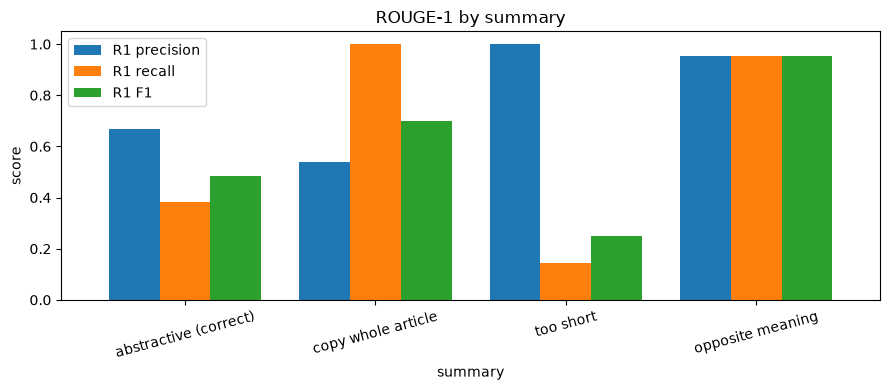

In [12]:
ax = rouge_df[["R1 precision", "R1 recall", "R1 F1"]].plot.bar(figsize=(9, 4), rot=15, width=0.8)
ax.set_ylabel("score"); ax.set_title("ROUGE-1 by summary"); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

Verify against Google's `rouge-score` package:

In [13]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
for name, s in summaries.items():
    lib = scorer.score(reference, s)   # signature: score(target, prediction)
    ours = (rouge_n(s, reference, 1)["f"], rouge_n(s, reference, 2)["f"], rouge_l(s, reference)["f"])
    theirs = (lib["rouge1"].fmeasure, lib["rouge2"].fmeasure, lib["rougeL"].fmeasure)
    assert np.allclose(ours, theirs), name
print("all match rouge-score")

all match rouge-score


Reading the chart:
- **copy whole article**: recall is high, precision is low. Recall alone rewards length, which is why F1 is the number to report.
- **too short**: high precision, tiny recall.
- **opposite meaning**: highest overlap of all, despite saying the reverse of the reference.

## 5. Failure modes (2 min)

Put BLEU and ROUGE side by side on the same summaries, next to a human judgment.

In [14]:
human = {"abstractive (correct)": "correct", "copy whole article": "correct but verbose",
         "too short": "incomplete", "opposite meaning": "WRONG"}

summary_scores = pd.DataFrame({
    "BLEU (smoothed)": {k: bleu(v, reference, smooth=True) for k, v in summaries.items()},
    "ROUGE-1 F1":      {k: rouge_n(v, reference, 1)["f"] for k, v in summaries.items()},
    "ROUGE-2 F1":      {k: rouge_n(v, reference, 2)["f"] for k, v in summaries.items()},
    "ROUGE-L F1":      {k: rouge_l(v, reference)["f"] for k, v in summaries.items()},
})

summary_scores["human judgment"] = pd.Series(human)
summary_scores.style.format(precision=3).background_gradient(cmap="Blues", subset=summary_scores.columns[:-1])

,BLEU (smoothed),ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,human judgment
abstractive (correct),0.093,0.485,0.129,0.364,correct
copy whole article,0.452,0.700,0.621,0.633,correct but verbose
too short,0.002,0.250,0.091,0.250,incomplete
opposite meaning,0.609,0.952,0.700,0.857,WRONG


The wrong summary outscores the correct paraphrase on every overlap metric. n-gram metrics cannot see negation, facts, or paraphrase.

They can also be gamed. Shuffle the reference's words and ROUGE-1 is perfect:

In [15]:
words = tokenize(reference)
random.Random(0).shuffle(words)
stuffed = " ".join(words)

print(stuffed, "\n")
print("ROUGE-1 F1:", round(rouge_n(stuffed, reference, 1)["f"], 3))
print("ROUGE-2 F1:", round(rouge_n(stuffed, reference, 2)["f"], 3))
print("ROUGE-L F1:", round(rouge_l(stuffed, reference)["f"], 3))

increases road spending transport the on funding council approved that new on a expansion budget and cuts tuesday city public for 

ROUGE-1 F1: 1.0
ROUGE-2 F1: 0.1
ROUGE-L F1: 0.333


Higher-order n-grams and LCS penalize the scrambling; unigram overlap does not.

### Cheat sheet

| | Accuracy | BLEU | ROUGE |
|---|---|---|---|
| Use for | one right answer | translation-like tasks | summarization-like tasks |
| Measures | exact match rate | clipped n-gram **precision** + brevity | n-gram / LCS **recall** (+ F1) |
| Range | 0-1 | 0-1 (sacrebleu: 0-100) | 0-1 |
| Gameable by | majority class; lenient parsing | copying reference words; short outputs w/o BP | length (recall); keyword stuffing (ROUGE-1) |
| Blind to | class-level failures | meaning, paraphrase, facts | meaning, negation, facts |
| Library | `sklearn.metrics` | `sacrebleu` | `rouge-score` |

**Beyond n-gram overlap:** embedding-based metrics (BERTScore), LLM-as-judge, human evaluation, and task-specific checks (e.g. unit tests for generated code). Use overlap metrics as cheap regression signals, not as ground truth for quality.

## Exercises

**1. Fix the parser.** Extend `extract_choice` so the three test strings below parse correctly.

In [ ]:
tests = ["I think it's C", "My pick: B", "Final answer - D"]
print([extract_choice(t) for t in tests])   # goal: ['C', 'B', 'D']

**2. Break BLEU.** Edit `my_candidate` so BLEU (smoothed) is at least 0.6 but the meaning is the **opposite** of the reference. Hint: one inserted word.

In [ ]:
ref = "the cat is sitting on the mat by the window"
my_candidate = "the cat is sitting on the mat by the window"   # edit me

score = bleu(my_candidate, ref, smooth=True)
print(f"BLEU (smoothed) = {score:.3f}", "-> goal reached" if score >= 0.6 and my_candidate != ref else "")

**3. Discussion.** Choose a metric (or say none suffices) and justify:
- (a) a translation system for legal documents
- (b) an LLM benchmark of 4-option science questions
- (c) an abstractive news summarizer
- (d) an open-ended customer-support chatbot